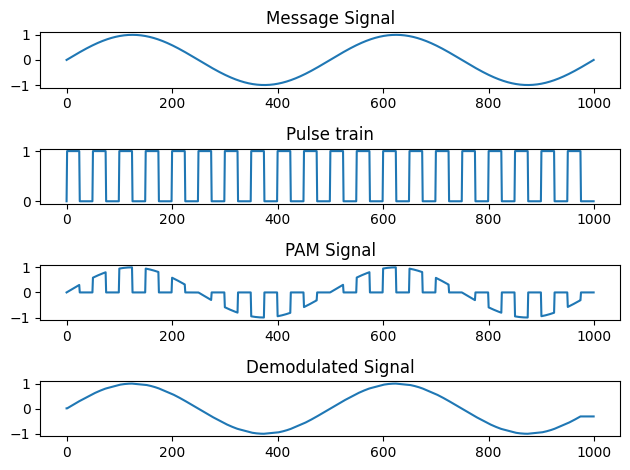

In [5]:
#LAB 1 & 5: PAM modulation and Demodulation

import numpy as np,matplotlib.pyplot as plt

t=np.linspace(0,1,1000)

m=np.sin(2*np.pi*2*t)

p=(np.sin(2*np.pi*20*t)>0).astype(int)

pam=m*p

i=np.where(p>0)[0]


d=np.interp(t,t[i],pam[i])

plt.subplot(4,1,1); plt.plot(m);plt.title("Message Signal")
plt.subplot(4,1,2); plt.plot(p);plt.title("Pulse train")
plt.subplot(4,1,3); plt.plot(pam);plt.title("PAM Signal")
plt.subplot(4,1,4); plt.plot(d);plt.title("Demodulated Signal")
plt.tight_layout()
plt.show()

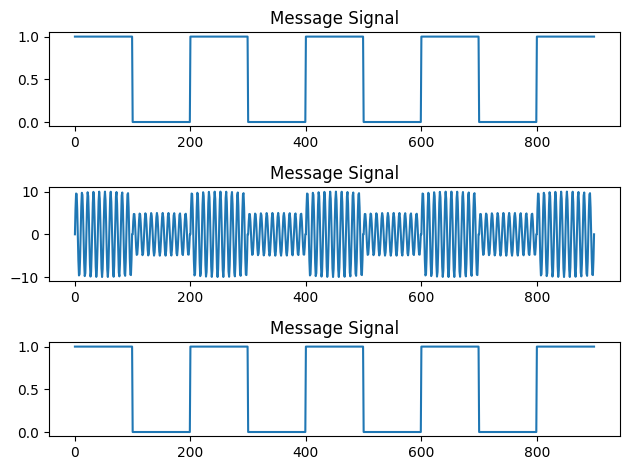

In [1]:
#ASK
import numpy as np,matplotlib.pyplot as plt
b=[1,0,1,0,1,0,1,0,1]; n=100;t=np.linspace(0,1,n);c=np.sin(2*np.pi*10*t)


d=np.repeat(b,n)
m=np.hstack([(10 if i else 5)*c for i in b])
r=np.array([1 if np.mean(abs(m[i*n:(i+1)*n]))>4.5 else 0 for i in range(len(b))])


rd=np.repeat(r,n)

plt.subplot(3,1,1); plt.plot(d);plt.title("Message Signal")
plt.subplot(3,1,2); plt.plot(m);plt.title("Message Signal")
plt.subplot(3,1,3); plt.plot(rd);plt.title("Message Signal")
plt.tight_layout()
plt.show()


Binary Information at Transmitter: [1 0 1 0 1 0 1 0 1]
Binary Information at Receiver: [1, 0, 1, 0, 1, 0, 1, 0, 1]


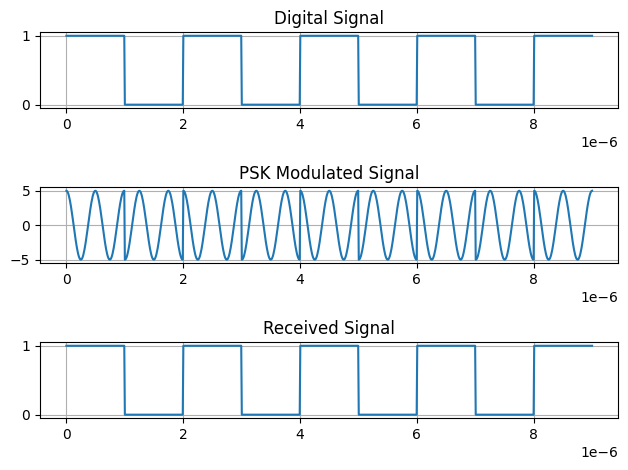

In [ ]:
#PSK
import numpy as np, matplotlib.pyplot as plt

x=np.array([1,0,1,0,1,0,1,0,1]); bp=1e-6
print("Binary Information at Transmitter:",x)

bit=np.repeat(x,100); t1=np.linspace(0,bp*len(x),len(bit))
plt.subplot(311); plt.plot(t1,bit); plt.title("Digital Signal"); plt.grid()

A=5; f=2/bp; t2=np.linspace(0,bp,100)
m=np.concatenate([A*np.cos(2*np.pi*f*t2+(0 if i else np.pi)) for i in x])
t3=np.linspace(0,bp*len(x),len(m))

plt.subplot(312); plt.plot(t3,m); plt.title("PSK Modulated Signal"); plt.grid()

ref=np.cos(2*np.pi*f*t2)
mn=[1 if (2*np.trapezoid(m[i*100:(i+1)*100]*ref,t2)/bp)>0 else 0 for i in range(len(x))]
print("Binary Information at Receiver:",mn)

bit_rec=np.repeat(mn,100); t4=np.linspace(0,bp*len(mn),len(bit_rec))
plt.subplot(313); plt.plot(t4,bit_rec); plt.title("Received Signal"); plt.grid()

plt.tight_layout(); plt.show()

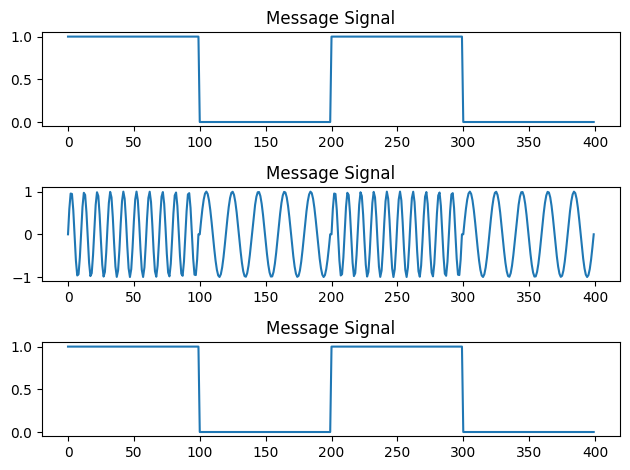

In [28]:
import numpy as np, matplotlib.pyplot as plt
b=[1,0,1,0]; n=100; t=np.linspace(0,1,n)
f1,f0=10,5

d=np.repeat(b,n)

m=np.hstack([np.sin(2*np.pi*(f1 if i else f0)*t) for i in b])

r=[1 if  np.sum(m[i*n:(i+1)*n]*np.sin(2*np.pi*f1*t))>np.sum(m[i*n:(i+1)*n]*np.sin(2*np.pi*f0*t)) else 0 for i in range(len(b))]

rd=np.repeat(r,n)

plt.subplot(3,1,1); plt.plot(d);plt.title("Message Signal")
plt.subplot(3,1,2); plt.plot(m);plt.title("Message Signal")
plt.subplot(3,1,3); plt.plot(rd);plt.title("Message Signal")
plt.tight_layout()
plt.show()
